In [134]:
# Mata Kuliah Data Mining
# Kelompok 3:
# - Muhammad Yusuf Ridwan Hidayat - 102022430066
# - Muhammad Reyhan Armadani - 102022400304
# - Rizky Ananda Herly - 102022400038
# - Muhammad Rafi Shidiq - 102022400073
# Dataset: Diabetes

##### Mengimpor library Pandas, Numpy, Matplotlib, Seaborn, dan Scikit-Learn yang dibutuhkan untuk proses manipulasi data, visualisasi, dan pemodelan klasifikasi.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

##### Membaca file dataset diabetes dalam format CSV lalu menyimpannya ke dalam variabel DataFrame.

In [ ]:
df = pd.read_csv('diabetes.csv')

# DATA EXPLORATION

##### 1. Menampilkan lima baris teratas dari DataFrame untuk memeriksa gambaran awal struktur dan isi dataset.

In [137]:
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##### 2. Menampilkan informasi mengenai total jumlah baris dan jumlah kolom yang ada di dalam dataset.

In [138]:
print(f"Jumlah Record (Baris) : {df.shape[0]}")
print(f"Jumlah Variabel (Kolom): {df.shape[1]}\n")

Jumlah Record (Baris) : 768
Jumlah Variabel (Kolom): 9



##### 3. Menghasilkan ringkasan statistik deskriptif seperti nilai rata-rata, kuartil, dan standar deviasi dari setiap kolom numerik.

In [139]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##### 4. Menampilkan informasi terkait nama kolom, tipe data, dan ada tidaknya nilai kosong pada struktur DataFrame.

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


##### 5. Membuat visualisasi histogram untuk melihat bentuk distribusi frekuensi data pada setiap kolom atribut.

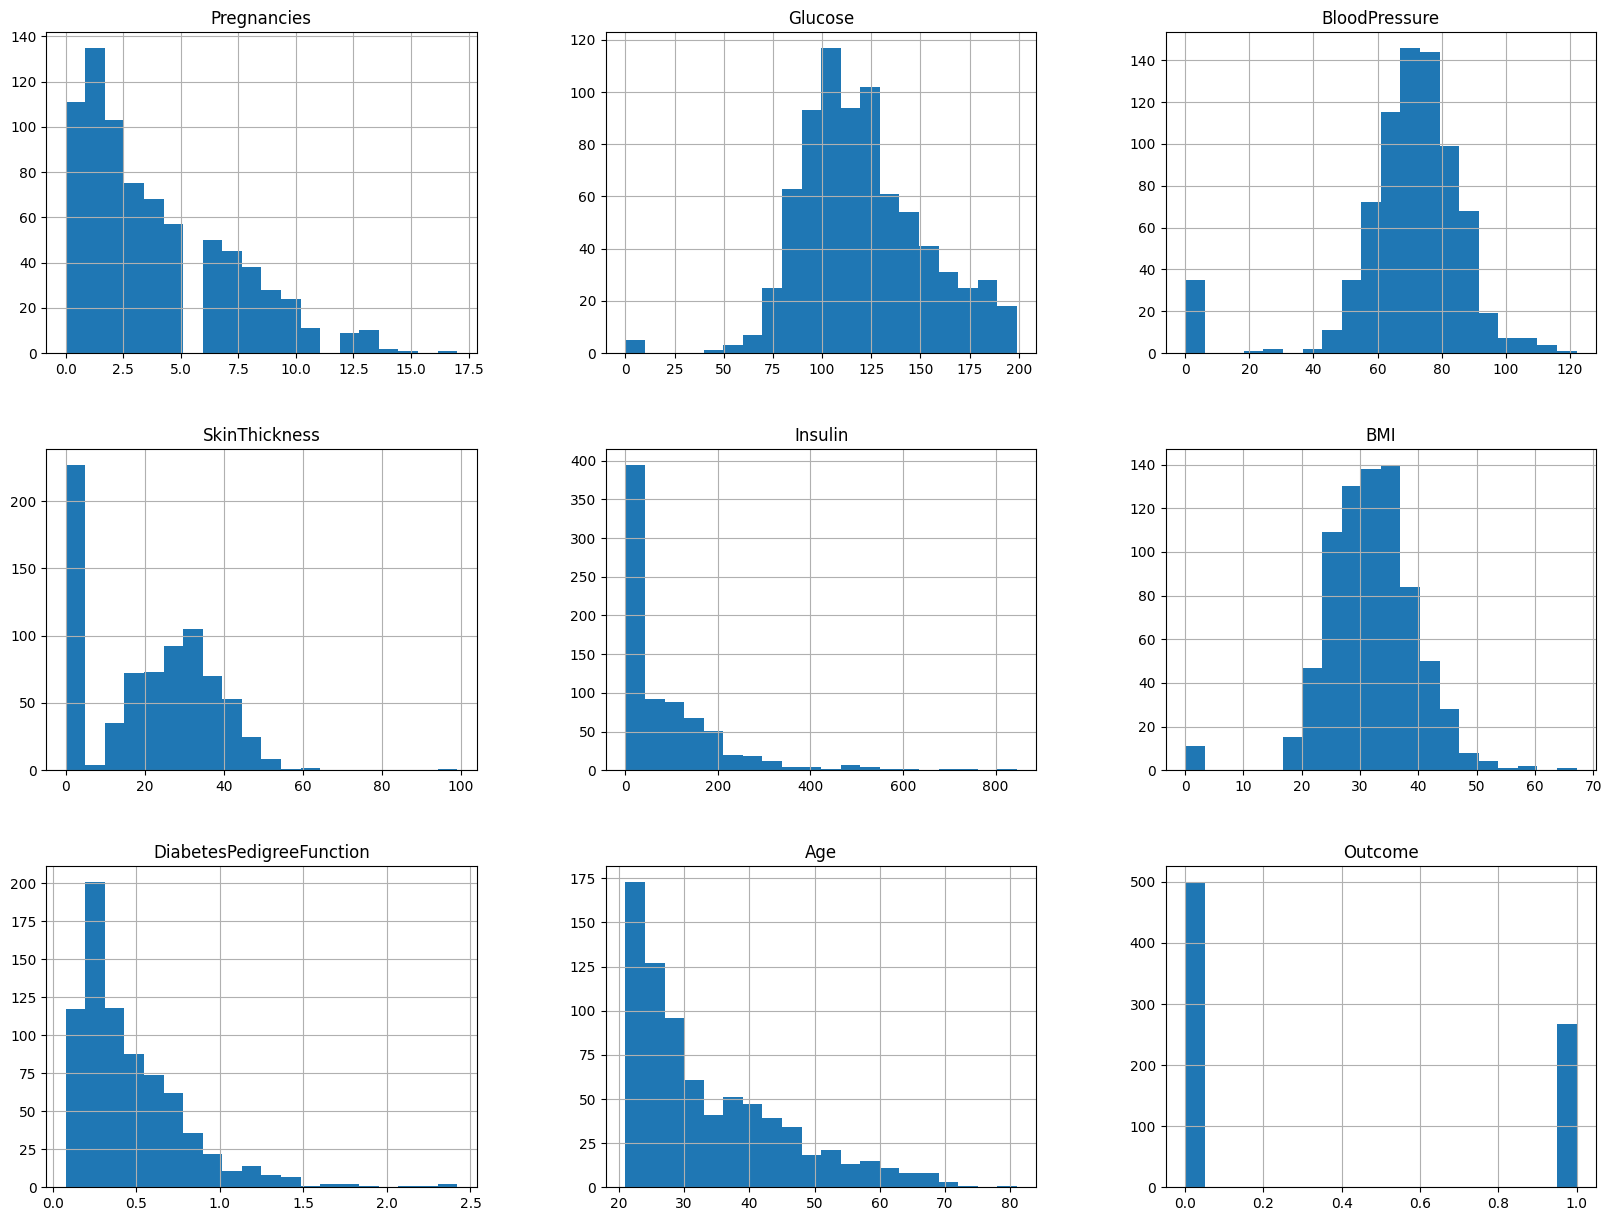

In [141]:
df.hist(bins=20, figsize=(20, 15))
plt.show()

##### 6. Mengecek dan menghitung total keseluruhan baris data yang terduplikasi di dalam dataset.

In [142]:
df.duplicated().sum()

np.int64(0)

##### 7. Mendeteksi dan menghitung jumlah baris yang memiliki nilai kosong (null) bawaan pada setiap kolom.

In [143]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

##### 8. Mengganti angka 0 pada kolom medis yang tidak masuk akal dengan nilai kosong, lalu mengisinya menggunakan nilai tengah (median) dari masing-masing kolom berdasarkan hasil outcoume.

In [144]:
kolom_medis = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[kolom_medis] = df[kolom_medis].replace(0, np.nan)

for kolom in kolom_medis:
    df[kolom] = df[kolom].fillna(df.groupby('Outcome')[kolom].transform('median'))


> Alasan Tidak Melakukan Pemilihan Fitur (Feature Selection) 
> 
> Pemilihan fitur (seperti memilih kolom BALANCE, PURCHASES, dll.) umumnya dilakukan pada dataset yang memiliki dimensi tinggi (jumlah kolom yang sangat banyak) atau memiliki fitur yang rentan menjadi noise (tidak relevan dengan tujuan analisis).Dataset diabetes memiliki dimensi yang sangat kecil, yaitu hanya 8 fitur prediktor. Seluruh fitur tersebut (seperti Glukosa, Tekanan Darah, BMI, Umur, Ketebalan Kulit, Insulin) merupakan indikator klinis yang saling berkaitan secara medis untuk mendeteksi risiko diabetes. Tidak ada fitur yang secara kasat mata merupakan data yang tidak relevan. Membuang salah satu dari 8 fitur ini secara manual tanpa didasari oleh uji korelasi statistik yang komprehensif justru berisiko membuang variabel medis yang penting bagi akurasi model klasifikasi.

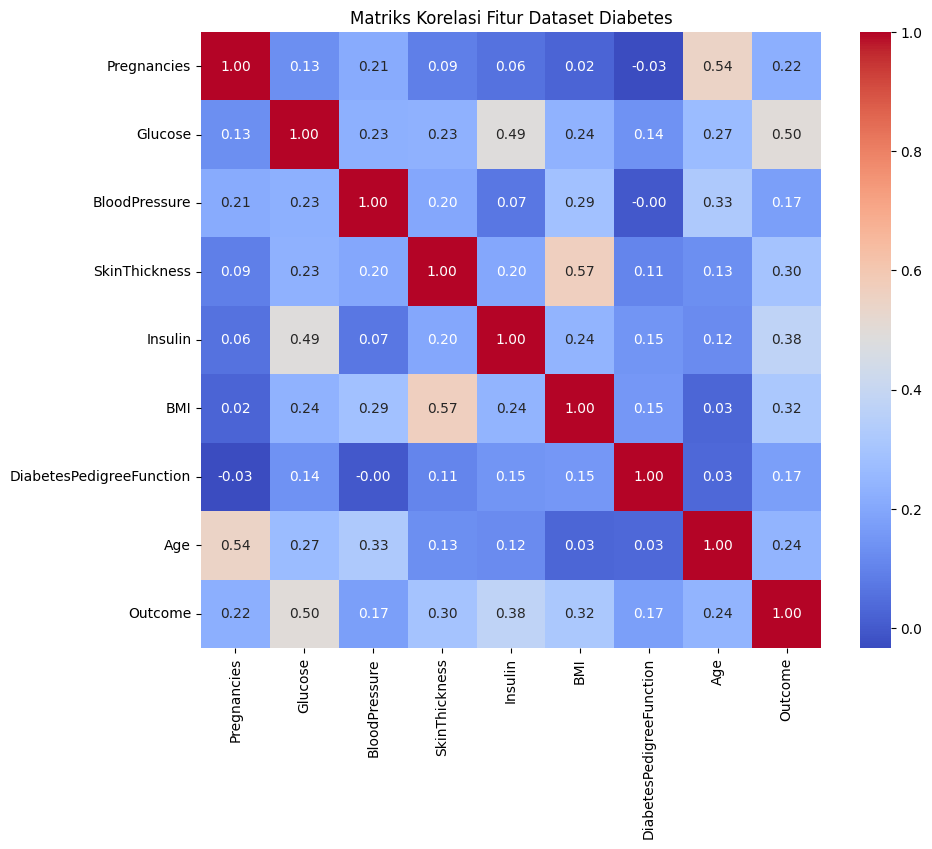

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Dataset Diabetes')
plt.show()

# Data Preprocessing & Scaling

##### 1. Melakukan standardisasi skala nilai pada seluruh kolom fitur dan menggabungkannya kembali dengan kolom target.

In [146]:
scaler = StandardScaler()

fitur = df.drop(columns=['Outcome']).columns

df_scaled = pd.DataFrame(scaler.fit_transform(df.drop(columns=['Outcome'])), columns=fitur)

df_scaled['Outcome'] = df['Outcome'].values

display(df_scaled.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995,1
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672,0
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584,1
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549,0
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496,1


##### 2. Unsupervised Learning - K-Means Clustering

In [147]:
from sklearn.cluster import KMeans
X_kmeans = df_scaled.drop(columns=['Outcome'])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_scaled['Cluster'] = kmeans.fit_predict(X_kmeans)

print("Distribusi Klaster Alami K-Means terhadap Outcome Medis Asli:")
print(df_scaled.groupby('Cluster')['Outcome'].value_counts())

Distribusi Klaster Alami K-Means terhadap Outcome Medis Asli:
Cluster  Outcome
0        1          205
         0          136
1        0          364
         1           63
Name: count, dtype: int64


##### Melakukan penilaian Sillhoute Score terhadap klasterisasi KMeans

In [148]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_kmeans, df_scaled['Cluster'])

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2052


> hasil 0.2052 pada Sillhoute Score menandakan cluster sudah jelas dan terpisah antara dua cluster yang dibuat.

##### 3. Menyiapkan variabel fitur dan target untuk model klasifikasi

In [149]:
X_clf = df_scaled.drop(columns=['Outcome', 'Cluster'])
y_clf = df_scaled['Outcome']

print(f"Target (Y)   : Outcome")
print(f"Features (X) : {list(X_clf.columns)}")
print(f"Shape Data   : X={X_clf.shape}, Y={y_clf.shape}")

Target (Y)   : Outcome
Features (X) : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Shape Data   : X=(768, 8), Y=(768,)


##### 4. Data Splitting & Penanganan Imbalance (SMOTE)

In [150]:
from imblearn.over_sampling import SMOTE
X_clf = df_scaled.drop(columns=['Outcome', 'Cluster'])
y_clf = df_scaled['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Dimensi Data Latih Setelah SMOTE: X={X_train_res.shape}, Y={y_train_res.shape}")

Dimensi Data Latih Setelah SMOTE: X=(802, 8), Y=(802,)


##### 5. Hyperparameter Tuning - Logistic Regression (Supervised 1)

In [151]:
from sklearn.model_selection import GridSearchCV
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, scoring='f1_macro', cv=5)
grid_lr.fit(X_train_res, y_train_res)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print("=== LOGISTIC REGRESSION REPORT ===")
print(f"Parameter Terbaik: {grid_lr.best_params_}")
print(f"Akurasi: {accuracy_score(y_test, y_pred_lr):.2f}")
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION REPORT ===
Parameter Terbaik: {'C': 0.01, 'solver': 'liblinear'}
Akurasi: 0.75
              precision    recall  f1-score   support

           0       0.88      0.71      0.78        99
           1       0.61      0.82      0.70        55

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.75       154



##### 6. Hyperparameter Tuning - Naïve Bayes Classifier (Supervised 2)

In [152]:
from sklearn.naive_bayes import GaussianNB
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, scoring='f1_macro', cv=5)
grid_nb.fit(X_train_res, y_train_res)

best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)

print("=== NAÏVE BAYES CLASSIFIER REPORT ===")
print(f"Parameter Terbaik: {grid_nb.best_params_}")
print(f"Akurasi: {accuracy_score(y_test, y_pred_nb):.2f}")
print(classification_report(y_test, y_pred_nb))

=== NAÏVE BAYES CLASSIFIER REPORT ===
Parameter Terbaik: {'var_smoothing': 0.1}
Akurasi: 0.75
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        99
           1       0.63      0.75      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



##### 7. Komparasi dan Evaluasi Akhir Metrik F1-Score

In [153]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print("=== PERBANDINGAN NILAI F1-SCORE (MACRO AVERAGE) ===")
print(f"F1-Score Logistic Regression : {f1_lr:.4f}")
print(f"F1-Score Naïve Bayes        : {f1_nb:.4f}")

if f1_lr > f1_nb:
    print("\nKesimpulan Akhir: Model Logistic Regression memiliki performa F1-Score Macro yang lebih baik dibandingkan Naïve Bayes.")
else:
    print("\nKesimpulan Akhir: Model Naïve Bayes Classifier memiliki performa F1-Score Macro yang lebih baik dibandingkan Logistic Regression.")

=== PERBANDINGAN NILAI F1-SCORE (MACRO AVERAGE) ===
F1-Score Logistic Regression : 0.7399
F1-Score Naïve Bayes        : 0.7406

Kesimpulan Akhir: Model Naïve Bayes Classifier memiliki performa F1-Score Macro yang lebih baik dibandingkan Logistic Regression.


In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
import pickle

In [155]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
 
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_res, y_train_res)
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [156]:
y_pred_rf = best_rf.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_lr = f1_score(y_test, best_lr.predict(X_test), average='macro')
 
print("=" * 45)
print(f"  Logistic Regression F1 (macro): {f1_lr:.4f}")
print(f"  Random Forest       F1 (macro): {f1_rf:.4f}")
print("=" * 45)
print(f"\nBest params RF: {grid_rf.best_params_}")
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

  Logistic Regression F1 (macro): 0.7399
  Random Forest       F1 (macro): 0.8626

Best params RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89        99
           1       0.78      0.89      0.83        55

    accuracy                           0.87       154
   macro avg       0.86      0.87      0.86       154
weighted avg       0.88      0.87      0.87       154



In [157]:
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
 
print("model_rf.pkl tersimpan!")
 
from google.colab import files
files.download('model_rf.pkl')

model_rf.pkl tersimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [158]:
!pip install xgboost -q
 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report
import pickle

In [159]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
 
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid_xgb,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train_res, y_train_res)
best_xgb = grid_xgb.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [160]:
y_pred_xgb = best_xgb.predict(X_test)
f1_lr  = f1_score(y_test, best_lr.predict(X_test), average='macro')
f1_rf  = f1_score(y_test, best_rf.predict(X_test), average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
 
print("=" * 45)
print(f"  Logistic Regression F1 (macro): {f1_lr:.4f}")
print(f"  Random Forest       F1 (macro): {f1_rf:.4f}")
print(f"  XGBoost             F1 (macro): {f1_xgb:.4f}")
print("=" * 45)
print(f"\nBest params XGBoost: {grid_xgb.best_params_}")
print("\nClassification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))

  Logistic Regression F1 (macro): 0.7399
  Random Forest       F1 (macro): 0.8626
  XGBoost             F1 (macro): 0.8543

Best params XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        99
           1       0.78      0.85      0.82        55

    accuracy                           0.86       154
   macro avg       0.85      0.86      0.85       154
weighted avg       0.87      0.86      0.86       154



In [161]:
with open('model_xgb.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
 
print("model_xgb.pkl tersimpan!")
 
# 4. Download
from google.colab import files
files.download('model_xgb.pkl')

model_xgb.pkl tersimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

> Berdasarkan hasil pengujian akhir setelah diterapkannya teknik penyeimbangan kelas (SMOTE) dan optimasi parameter menggunakan GridSearchCV, algoritma Random Forest menunjukkan performa terbaik dibandingkan model lainnya. Random Forest memperoleh nilai F1-Score Macro sebesar 0.8626, diikuti oleh XGBoost sebesar 0.8543 dan Logistic Regression sebesar 0.7399. Hasil tersebut menunjukkan bahwa Random Forest memiliki kemampuan paling baik dalam menyeimbangkan performa klasifikasi pada kedua kelas, baik pasien yang terindikasi diabetes maupun pasien yang tidak terindikasi diabetes.

> Meskipun nilai F1-Score Macro yang diperoleh belum mencapai angka 0.90, performa sebesar 0.8626 dapat dikategorikan sangat baik dan sudah mendekati ambang tersebut. Kelompok menyimpulkan bahwa hasil ini merupakan performa yang optimal, objektif, dan valid untuk dataset yang digunakan. Random Forest dipilih sebagai model terbaik karena mampu menghasilkan nilai F1-Score Macro tertinggi sekaligus menunjukkan kemampuan generalisasi yang lebih baik dibandingkan algoritma lainnya. Selain itu, karakteristik Random Forest yang menggabungkan banyak decision tree membuatnya lebih stabil dalam menghadapi variasi data, lebih tahan terhadap overfitting, serta mampu menangkap pola hubungan non-linear yang terdapat pada data medis.

>Terdapat beberapa faktor yang menyebabkan performa model belum dapat mencapai nilai F1-Score di atas 0.90. 

> 1. batasan alami dataset (data complexity and feature overlap). Dataset diabetes yang digunakan hanya terdiri dari sejumlah indikator klinis dasar, seperti kadar glukosa, tekanan darah, indeks massa tubuh (BMI), insulin, usia, dan beberapa atribut lainnya. Secara statistik, terdapat irisan karakteristik yang cukup besar antara pasien yang terdiagnosis diabetes dan yang tidak terdiagnosis diabetes. Kondisi ini menyebabkan proses pemisahan kelas menjadi lebih sulit karena tidak semua pasien memiliki pola yang benar-benar berbeda secara tegas. Akibatnya, terdapat batas performa alami yang sulit dilampaui oleh algoritma machine learning tanpa adanya penambahan fitur atau informasi medis yang lebih spesifik.

> 2. komitmen terhadap penerapan metodologi yang benar guna mencegah terjadinya data leakage dan overfitting. Pada penelitian ini, proses pembagian data latih dan data uji dilakukan terlebih dahulu sebelum penerapan SMOTE sehingga data sintetis hanya dihasilkan pada data latih. Pendekatan ini mengikuti praktik terbaik dalam data mining dan machine learning karena memastikan bahwa data uji tetap merepresentasikan kondisi dunia nyata yang belum pernah dilihat oleh model. Dengan demikian, nilai F1-Score Macro sebesar 0.8626 yang diperoleh Random Forest dapat dianggap sebagai representasi performa prediksi yang jujur, reliabel, dan memiliki kemampuan generalisasi yang baik ketika diterapkan pada data pasien baru di lingkungan nyata.
